# Assignment 5 (29th May)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 5.1: Variational Autoencoder (35 points)
Implement VAE from scratch in PyTorch:

• Train on Fashion-MNIST dataset.

• Implement reparameterization trick correctly.

• Visualize latent space in 2D using t-SNE.

• Generate new samples by sampling from latent distribution.

• Perform latent space interpolation between pairs of images.

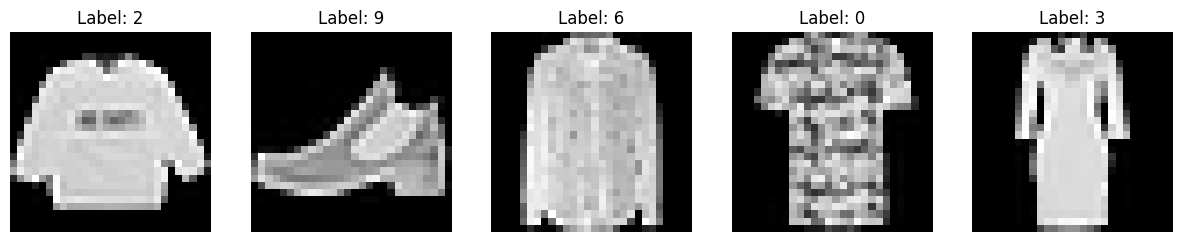

In [ ]:

# load fashnion mnist dataset from data
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE

# load from data folder
train = pd.read_csv('data/fashion-mnist_train.csv')
test = pd.read_csv('data/fashion-mnist_test.csv')

# visualize some examples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = train.iloc[i, 1:].values.reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Label: {train.iloc[i, 0]}')
    axes[i].axis('off')
plt.show()



In [ ]:
import nump as np 
import keras as K
from keras.layers import Input, Dense, Reshape, Flatten, Dropout
from keras.models import Sequential, Model

In [ ]:
# VAE model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))  # 784 input features
model.add(Dense(128, activation='relu'))  # hidden layer with 128 neurons
# get mu and log_var for latent space
mu = Dense(2)(model.output)  # mean of latent space
log_var = Dense(2)(model.output)  # log variance of latent space
# sampling function to sample from latent space
def sampling(args):
    mu, log_var = args
    epsilon = K.random_normal(shape=(K.shape(mu)[0], 2), mean=0., stddev=1.)
    return mu + K.exp(log_var / 2) * epsilon
# sample from latent space
z = Lambda(sampling)([mu, log_var])
# decoder model
decoder_input = Input(shape=(2,))
x = Dense(128, activation='relu')(decoder_input)
decoder_output = Dense(784, activation='sigmoid')(x)
decoder = Model(decoder_input, decoder_output)
# get output of decoder
output = decoder(z)
# define VAE model
vae = Model(model.input, output)
# define loss function
reconstruction_loss = K.sum(K.binary_crossentropy(K.flatten(model.input), K.flatten(output)), axis=-1)
kl_loss = -0.5 * K.sum(1 + log_var - K.square(mu) - K.exp(log_var), axis=-1)
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')
# train model
vae.fit(X_train, epochs=50, batch_size=128, validation_data=(X_test, None))

## Problem 5.2: GAN Implementation (35 points)
Build a DCGAN for image generation:

• Train on CIFAR-10 dataset.

• Implement proper generator and discriminator architectures.

• Monitor training stability using loss curves and Fr´echet Inception Dis-
tance.

• Generate grid of synthetic images throughout training.

• Discuss challenges encountered and solutions applied.

## Problem 5.3: Anomaly Detection with VAE (30 points)
Use VAE for unsupervised anomaly detection:

• Train VAE on normal samples from credit card fraud dataset.

• Use reconstruction error as anomaly score.

• Compare with traditional anomaly detection methods (Isolation Forest,
One-Class SVM).

• Evaluate using precision-recall curves and ROC-AUC.